Loaded shape: (12228, 27)
Usable shape (non-missing key cols): (12228, 27)
Using columns:
  date_col = Datetime
  volume_col = Volume
  volatility_col = 7D_EWMA_Intraday_Price_Volatility
  return_col = Return


7D_EWMA_Intraday_Price_Volatility                      \
                                             count      mean    median   
Volume_Regime                                                            
High (top 25%)                                3059  0.087131  0.074900   
Low (bottom 25%)                              3059  0.035103  0.033047   
Medium                                        6110  0.048229  0.045761   

                           Return                               Volume  \
                       std  count      mean    median       std  count   
Volume_Regime                                                            
High (top 25%)    0.052411   3059  0.004910  0.003154  0.087893   3059   
Low (bottom 25%)  0.013953   3059 -0.000226 -0.000018  0.019740   3059   
Medium            0.016780   6110 -0.000037  0.000807  0.033966   6110   

                                                            
                          mean        median           std  
Volume_Regime                                               
High (top 25%)    1.088146e+09  2.356245e+06  4.222468e+09  
Low (bottom 25%)  4.958822e+07  2.859340e+05  8.778105e+07  
Medium            2.003472e+08  6.939794e+05  3.598525e+08

/var/folders/7f/9wc86j75083b9wyftzlwny0r0000gn/T/ipykernel_80942/1657766745.py:128: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data_box, labels=order, showfliers=False)


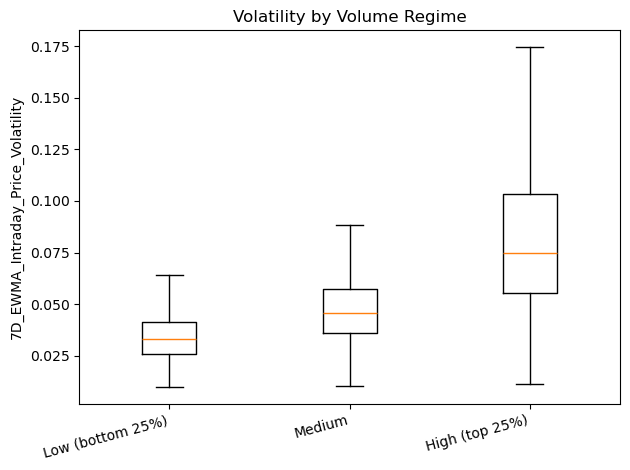

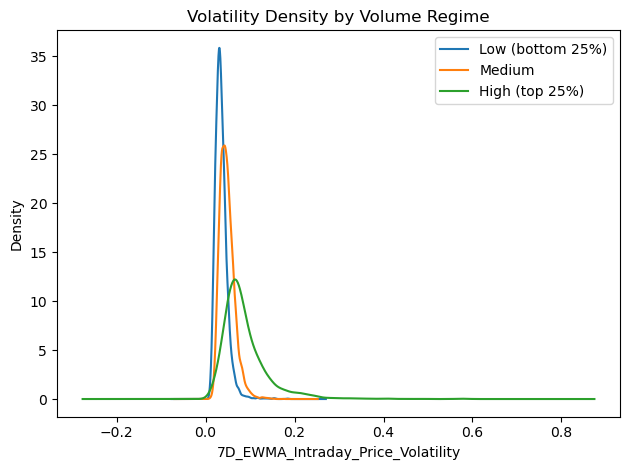

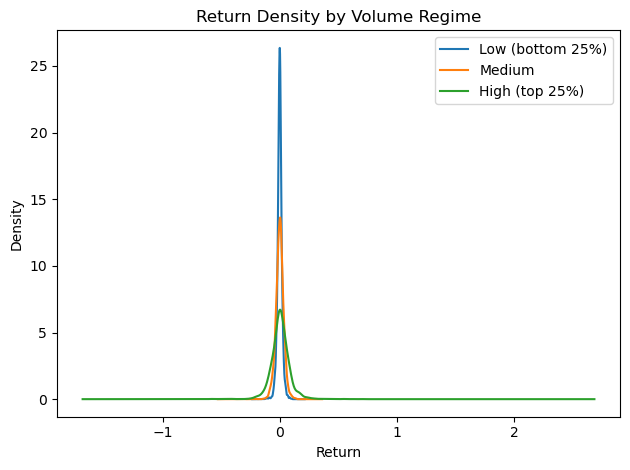

,lag_k,corr
0,-10,0.317535
1,-9,0.328467
2,-8,0.343871
3,-7,0.368400
4,-6,0.383037
5,-5,0.395491
6,-4,0.416254
7,-3,0.442661
8,-2,0.480274
9,-1,0.555068


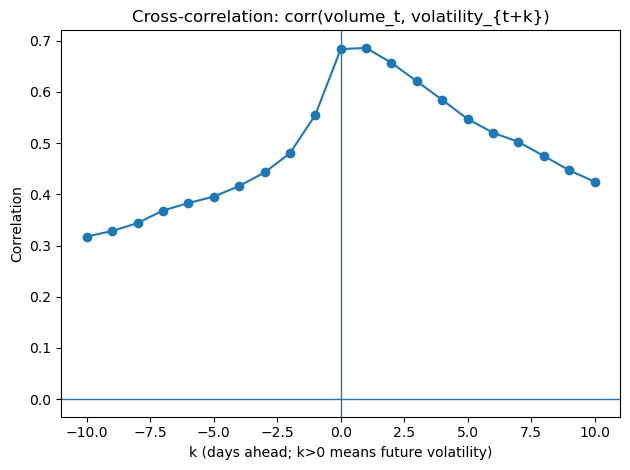

corr(volume_t, volatility_{t+1}) = 0.5482685150192966
Extreme days (top 5% volume): 612


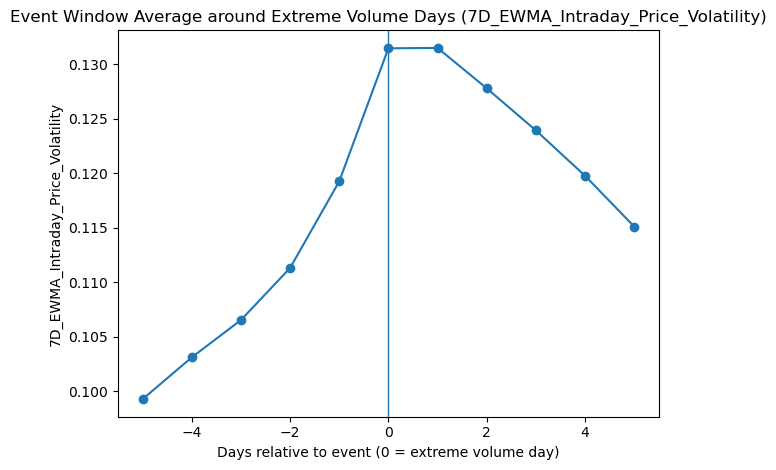

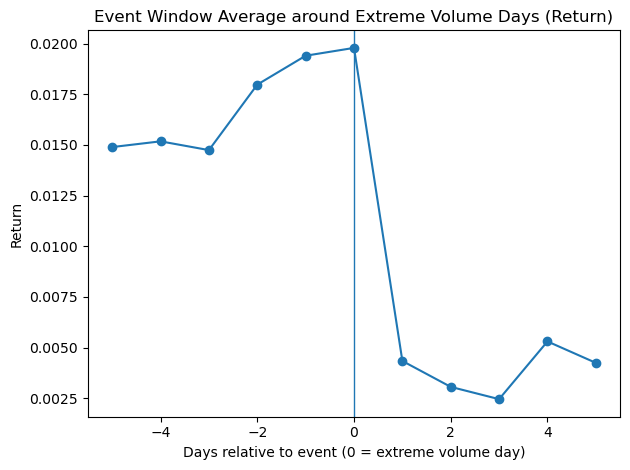

7D_EWMA_Intraday_Price_Volatility                                \
                                          count      mean    median       std   
ExtremeVolume                                                                   
False                                     11616  0.050631  0.045069  0.025284   
True                                        612  0.131472  0.114533  0.082307   

              Return                               Volume                \
               count      mean    median       std  count          mean   
ExtremeVolume                                                             
False          11616  0.000171  0.000625  0.038721  11616  2.491598e+08   
True             612  0.019784  0.012839  0.152891    612  2.957861e+09   

                                          
                    median           std  
ExtremeVolume                             
False           774656.564  6.409298e+08  
True           4575960.505  8.896977e+09

                            OLS Regression Results                            
Dep. Variable:               vol_next   R-squared:                       0.909
Model:                            OLS   Adj. R-squared:                  0.909
Method:                 Least Squares   F-statistic:                 6.141e+04
Date:                Wed, 11 Feb 2026   Prob (F-statistic):               0.00
Time:                        21:35:28   Log-Likelihood:                 38171.
No. Observations:               12227   AIC:                        -7.634e+04
Df Residuals:                   12224   BIC:                        -7.631e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Config
# -----------------------------
FILE_PATH = "/Users/qiuji/Downloads/merged_data.xlsx"

# Choose columns (auto-detect with fallbacks)
VOLUME_CANDIDATES = ["Volume", "Log_Volume"]
VOLATILITY_CANDIDATES = [
    "7D_EWMA_Intraday_Price_Volatility",
    "Volatility of Intraday Price",
]
RETURN_CANDIDATES = ["Return", "Lagged_Return"]  # prefer "Return"
DATE_CANDIDATES = ["Datetime", "Date"]

# Analysis params
LOW_Q = 0.25
HIGH_Q = 0.75
EXTREME_Q = 0.95
MAX_LAG = 10
EVENT_WINDOW = 5  # +/- days

# -----------------------------
# Load & clean
# -----------------------------
df = pd.read_excel(FILE_PATH)

def pick_col(candidates, df_cols):
    for c in candidates:
        if c in df_cols:
            return c
    return None

date_col = pick_col(DATE_CANDIDATES, df.columns)
ret_col = pick_col(RETURN_CANDIDATES, df.columns)
vol_col = pick_col(VOLATILITY_CANDIDATES, df.columns)

# pick volume: prefer raw Volume for regime + extreme event selection,
# but we will also compute log-volume if missing
volu_raw_col = "Volume" if "Volume" in df.columns else pick_col(VOLUME_CANDIDATES, df.columns)
if volu_raw_col is None:
    raise ValueError("No volume column found. Expected one of: " + ", ".join(VOLUME_CANDIDATES))

# Ensure datetime
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values([c for c in ["Symbol", date_col] if c in df.columns]).reset_index(drop=True)

# Ensure log volume exists (for regression)
if "Log_Volume" not in df.columns and "Volume" in df.columns:
    df["Log_Volume"] = np.log(df["Volume"].clip(lower=1e-12))

# If volatility column missing, compute rolling std of returns (7-day)
if vol_col is None:
    if ret_col is None:
        raise ValueError("No volatility column and no return column to compute it from.")
    vol_col = "Volatility_7D_RollingStd"
    if "Symbol" in df.columns:
        df[vol_col] = df.groupby("Symbol")[ret_col].transform(lambda s: s.rolling(7, min_periods=5).std())
    else:
        df[vol_col] = df[ret_col].rolling(7, min_periods=5).std()

# If return column missing, compute simple returns from Close (fallback)
if ret_col is None and "Close" in df.columns:
    ret_col = "Return_from_Close"
    if "Symbol" in df.columns:
        df[ret_col] = df.groupby("Symbol")["Close"].pct_change()
    else:
        df[ret_col] = df["Close"].pct_change()

# Drop rows with required values missing
req_cols = [volu_raw_col, vol_col, ret_col, date_col]
df0 = df.dropna(subset=req_cols).copy()

print("Loaded shape:", df.shape)
print("Usable shape (non-missing key cols):", df0.shape)
print("Using columns:")
print("  date_col =", date_col)
print("  volume_col =", volu_raw_col)
print("  volatility_col =", vol_col)
print("  return_col =", ret_col)

# -----------------------------
# Helper: volume regimes
# -----------------------------
def add_volume_regime(data, volume_col, low_q=0.25, high_q=0.75, by_symbol=True):
    out = data.copy()
    if by_symbol and "Symbol" in out.columns:
        q = out.groupby("Symbol")[volume_col].quantile([low_q, high_q]).unstack()
        q.columns = ["q_low", "q_high"]
        out = out.merge(q, left_on="Symbol", right_index=True, how="left")
    else:
        q_low = out[volume_col].quantile(low_q)
        q_high = out[volume_col].quantile(high_q)
        out["q_low"] = q_low
        out["q_high"] = q_high
    
    def regime(row):
        if row[volume_col] <= row["q_low"]:
            return "Low (bottom 25%)"
        elif row[volume_col] >= row["q_high"]:
            return "High (top 25%)"
        else:
            return "Medium"
    
    out["Volume_Regime"] = out.apply(regime, axis=1)
    out.drop(columns=["q_low", "q_high"], inplace=True)
    return out

df_reg = add_volume_regime(df0, volu_raw_col, LOW_Q, HIGH_Q, by_symbol=("Symbol" in df0.columns))

# ============================================================
# Part 1: Volume Regime Analysis (Q1)
# ============================================================
summary = (
    df_reg.groupby("Volume_Regime")[[vol_col, ret_col, volu_raw_col]]
    .agg(["count", "mean", "median", "std"])
    .sort_index()
)
display(summary)

order = ["Low (bottom 25%)", "Medium", "High (top 25%)"]
data_box = [df_reg.loc[df_reg["Volume_Regime"] == k, vol_col].values for k in order]

plt.figure()
plt.boxplot(data_box, labels=order, showfliers=False)
plt.ylabel(vol_col)
plt.title("Volatility by Volume Regime")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

plt.figure()
for k in order:
    s = df_reg.loc[df_reg["Volume_Regime"] == k, vol_col].dropna()
    if len(s) > 50:
        s.plot(kind="kde", label=k)
plt.title("Volatility Density by Volume Regime")
plt.xlabel(vol_col)
plt.legend()
plt.tight_layout()
plt.show()

plt.figure()
for k in order:
    s = df_reg.loc[df_reg["Volume_Regime"] == k, ret_col].dropna()
    if len(s) > 50:
        s.plot(kind="kde", label=k)
plt.title("Return Density by Volume Regime")
plt.xlabel(ret_col)
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Part 2: Lag Analysis (Q2)
# corr(volume_t, volatility_{t+k})
# ============================================================
def lag_corr(data, volume_col, volatility_col, max_lag=10, by_symbol=True):
    rows = []
    if by_symbol and "Symbol" in data.columns:
        groups = data.groupby("Symbol")
    else:
        groups = [("ALL", data)]
    
    for name, g in groups:
        g = g.sort_values(date_col)
        v = g[volume_col].astype(float)
        vol = g[volatility_col].astype(float)
        for k in range(-max_lag, max_lag + 1):
            corr = v.corr(vol.shift(-k))
            rows.append({"Symbol": name, "lag_k": k, "corr": corr})
    return pd.DataFrame(rows)

cc = lag_corr(df0, volu_raw_col, vol_col, MAX_LAG, by_symbol=("Symbol" in df0.columns))

if "Symbol" in df0.columns:
    cc_avg = cc.groupby("lag_k")["corr"].mean().reset_index()
    display(cc_avg)
else:
    cc_avg = cc.copy()

plt.figure()
plt.plot(cc_avg["lag_k"], cc_avg["corr"], marker="o")
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.title("Cross-correlation: corr(volume_t, volatility_{t+k})")
plt.xlabel("k (days ahead; k>0 means future volatility)")
plt.ylabel("Correlation")
plt.tight_layout()
plt.show()

corr_t_t1 = df0[volu_raw_col].corr(df0[vol_col].shift(-1))
print("corr(volume_t, volatility_{t+1}) =", corr_t_t1)

# ============================================================
# Part 3: Extreme Event Analysis (Q3)
# top 5% volume + event window ±5
# ============================================================
def mark_extreme_volume(data, volume_col, q=0.95, by_symbol=True):
    out = data.copy()
    if by_symbol and "Symbol" in out.columns:
        thresh = out.groupby("Symbol")[volume_col].transform(lambda s: s.quantile(q))
        out["ExtremeVolume"] = out[volume_col] >= thresh
        out["Extreme_Threshold"] = thresh
    else:
        thresh = out[volume_col].quantile(q)
        out["ExtremeVolume"] = out[volume_col] >= thresh
        out["Extreme_Threshold"] = thresh
    return out

df_ext = mark_extreme_volume(df0, volu_raw_col, EXTREME_Q, by_symbol=("Symbol" in df0.columns))
print("Extreme days (top 5% volume):", int(df_ext["ExtremeVolume"].sum()))

def event_window_average(data, is_event_col, value_cols, window=5, by_symbol=True):
    out_rows = []
    if by_symbol and "Symbol" in data.columns:
        groups = data.groupby("Symbol")
    else:
        groups = [("ALL", data)]
    
    for name, g in groups:
        g = g.sort_values(date_col).reset_index(drop=True)
        event_idx = g.index[g[is_event_col].astype(bool)].tolist()
        if not event_idx:
            continue
        
        for col in value_cols:
            mats = []
            for i in event_idx:
                lo = i - window
                hi = i + window
                if lo < 0 or hi >= len(g):
                    continue
                mats.append(g.loc[lo:hi, col].values)
            if not mats:
                continue
            mat = np.vstack(mats)
            mean = mat.mean(axis=0)
            out_rows.append({
                "Symbol": name,
                "metric": col,
                "n_events_used": len(mats),
                "series": mean
            })
    return out_rows

ew = event_window_average(
    df_ext,
    is_event_col="ExtremeVolume",
    value_cols=[vol_col, ret_col],
    window=EVENT_WINDOW,
    by_symbol=("Symbol" in df0.columns)
)

x = np.arange(-EVENT_WINDOW, EVENT_WINDOW + 1)

def plot_event_metric(ew_rows, metric_name):
    series_list = [r["series"] for r in ew_rows if r["metric"] == metric_name]
    if not series_list:
        print("No event-window series for:", metric_name)
        return
    mean_series = np.vstack(series_list).mean(axis=0)
    plt.figure()
    plt.plot(x, mean_series, marker="o")
    plt.axvline(0, linewidth=1)
    plt.title(f"Event Window Average around Extreme Volume Days ({metric_name})")
    plt.xlabel("Days relative to event (0 = extreme volume day)")
    plt.ylabel(metric_name)
    plt.tight_layout()
    plt.show()

plot_event_metric(ew, vol_col)
plot_event_metric(ew, ret_col)

comp = df_ext.groupby("ExtremeVolume")[[vol_col, ret_col, volu_raw_col]].agg(["count", "mean", "median", "std"])
display(comp)

# ============================================================
# Part 4 (Optional): Simple predictive regression
# Predict next-day volatility using current log-volume + current volatility
# ============================================================
try:
    import statsmodels.api as sm
    
    tmp = df0.copy()
    tmp["vol_next"] = tmp[vol_col].shift(-1)
    X = tmp[["Log_Volume", vol_col]].copy()
    y = tmp["vol_next"]
    model_df = pd.concat([X, y], axis=1).dropna()
    
    X2 = sm.add_constant(model_df[["Log_Volume", vol_col]])
    y2 = model_df["vol_next"]
    ols = sm.OLS(y2, X2).fit()
    
    print(ols.summary())
except Exception as e:
    print("Statsmodels regression skipped (statsmodels not available or error):", e)
